In [3]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt

In [4]:
# load data 
df = pd.read_csv("data/Salary_dataset.csv")

In [5]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [8]:
df.shape

(30, 3)

In [9]:
df = df.drop(columns=["Unnamed: 0"])

In [10]:
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [12]:
df.YearsExperience.dtype

dtype('float64')

In [13]:
df.Salary.dtype

dtype('float64')

In [6]:
predictors = ["YearsExperience"]
target = "Salary"

x = df[predictors]
y = df[target]

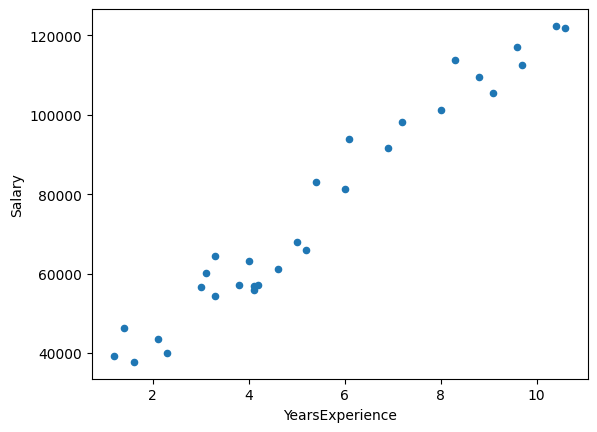

<Figure size 200x100 with 0 Axes>

In [21]:
# explore the relationship between the two 
df.plot.scatter(x="YearsExperience", y="Salary")

plt.figure(figsize=(2,1), layout="constrained")
plt.show()

In [7]:
model = LinearRegression()
model.fit(x, y)

# whether we're fitting or predicting, x should always be 2D array or pandas df (ndim = 2)
# y should be a np array or pandas series (ndim = 1)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
print(f"Intercept: {model.intercept_:.3f}")
print(f"YearsExperience Coefficient: {model.coef_[0]:.3f}")

# with every added year of experience, there's a $9,450 increase in salary

Intercept: 24848.204
YearsExperience Coefficient: 9449.962


C:\Users\USER\Desktop\Dev Space\ML\playground\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


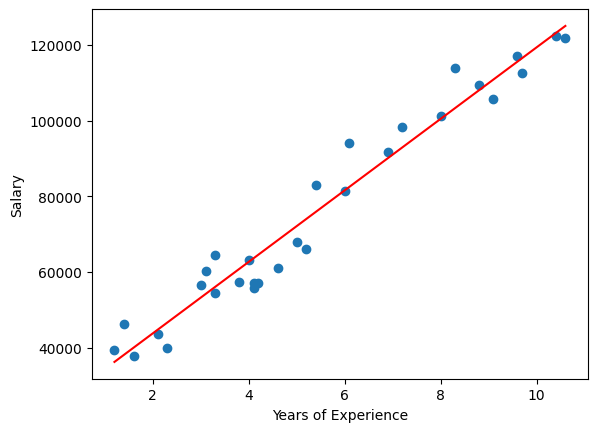

<Figure size 100x100 with 0 Axes>

In [52]:
# let's see the fitted line on the scatterplot 

# we can either use the already existing x values or use np to create random ones within range
x_vals = np.linspace(df["YearsExperience"].min(), df["YearsExperience"].max(), 100).reshape((-1, len(predictors)))

# y values will be the predicted values for x_vals
y_vals = model.predict(x_vals)

# we use plt.plot or so, directly when we want to have a lot of control instead of df.plot 
plt.scatter(x, y)
plt.plot(x_vals, y_vals, color="red")

plt.xlabel("Years of Experience")
plt.ylabel("Salary")

plt.figure(figsize=(1,1), layout="constrained")
plt.show()

In [9]:
# Assess the model
fitted = model.predict(x)

r2 = r2_score(y, fitted)
rmse = np.sqrt(mean_squared_error(y, fitted))

print(f"R2: {r2:.2f}")
print(f"RMSE: {rmse:.2f}")

# r2 score is 1 meaning the model explains all the variability in Salary
# This is not necessarily good. It might suggest overfitting 
# due to a tiny dataset
#R² computed on training data while RMSE computed on test data

R2: 0.96
RMSE: 5592.04


In [62]:
# RMSE is only 7% or the range. That's a small typical prediction error
(rmse / (y.max() - y.min())) * 100

np.float64(6.605296017907703)

In [63]:
# RMSE << std the model is genuinely learning something
np.std(y)

np.float64(26953.65024877583)

In [64]:
y.max() - y.min()

np.float64(84660.0)

In [66]:
# if R2 is ever 1, then RMSE should be 0 too 

,YearsExperience
0,1.2
1,1.4
2,1.6
3,2.1
4,2.3
5,3.0
6,3.1
7,3.3
8,3.3
9,3.8


In [6]:
# Using statsmodel
model = sm.OLS(y, x.assign(const=1))
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Salary   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     622.5
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           1.14e-20
Time:                        07:05:32   Log-Likelihood:                -301.44
No. Observations:                  30   AIC:                             606.9
Df Residuals:                      28   BIC:                             609.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
YearsExperience  9449.9623    378.755     24.950      0.000    8674.119    1.02e+04
const            2.485e+04   2306.654     10.772      0.000    2.01e+04    2.96e+04
==============================================================================
Omnibus:                        2.140   Durbin-Watson:                   1.648
Prob(Omnibus):                  0.343   Jarque-Bera (JB):                1.569
Skew:                           0.363   Prob(JB):                        0.456
Kurtosis:                       2.147   Cond. No.                         13.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [23]:
# cross validation
scores = cross_val_score(model, x, y, scoring="r2", cv=5)
print(scores)
np.mean(scores)

# One bad split: Any outlier row in a test fold can swing the score dramatically
# Linear regression is sensitive to small data
# Different folds = different “stories”

# R² is especially unstable on small samples: meaning a small change in the sample (like an added outlier) can have a significant effect on it
# Also, in small samples, total variability (SStol) is usually low; this makes even normal prediction errors look big and causes R2 to drop

[ 0.3595933  -1.24422823  0.25052696  0.29699762  0.07028896]


np.float64(-0.053364276845097834)

In [24]:
# cross validation with RMSE 
scores = cross_val_score(model, x, y, scoring="neg_root_mean_squared_error", cv=5)
rmse = -scores
print(rmse)
np.mean(rmse)

# RMSE is often more stable with small datasets

[5089.70910462 5565.4891967  7731.79553004 8271.45925566 5980.52992967]


np.float64(6527.7966033387)